In [6]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ashitham0207
/kaggle/input/datasets/ashitham0207/clinical
/kaggle/input/datasets/ashitham0207/clinical/Clinical Pregnancy Outcome in Fresh IVFICSI Treatment Between Cleavage-stage (Day 3) and Blastocyst-stage (Day 5) Embryo Transfer in Post Ovarian Stimulated Patient A Single-Centre Retrospective Analysis
/kaggle/input/datasets/iamshahzaibkhan
/kaggle/input/datasets/iamshahzaibkhan/human-blastocyst-dataset-for-ivf
/kaggle/input/datasets/iamshahzaibkhan/human-blastocyst-dataset-for-ivf/Images
/kaggle/input/datasets/iamshahzaibkhan/human-blastocyst-dataset-for-ivf/Images/Images


In [7]:
import os

path = "/kaggle/input/datasets/iamshahzaibkhan/human-blastocyst-dataset-for-ivf/Images/Images"

files = os.listdir(path)

print("Total images:", len(files))
print("First 5 images:", files[:5])

Total images: 2344
First 5 images: ['678_01.png', '754_01.png', '808_01.png', '210_06.png', '719_01.png']


(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

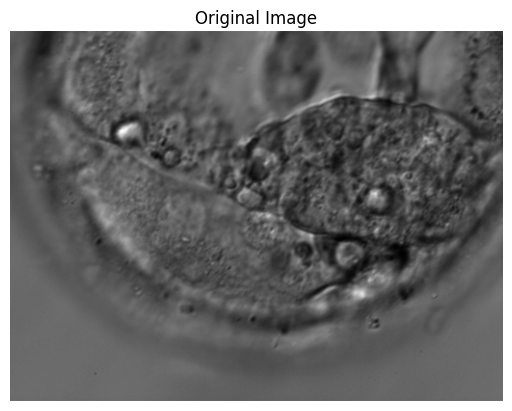

In [8]:
import cv2
import matplotlib.pyplot as plt

img_path = path + "/" + files[0]   # first image

img = cv2.imread(img_path, 0)  # grayscale

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

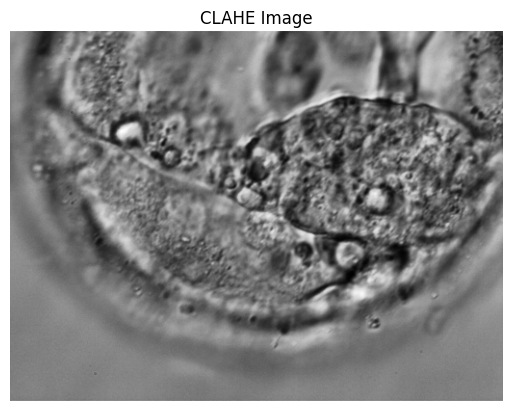

In [9]:
clahe = cv2.createCLAHE(clipLimit=1.8, tileGridSize=(8,8))
clahe_img = clahe.apply(img)

plt.imshow(clahe_img, cmap='gray')
plt.title("CLAHE Image")
plt.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

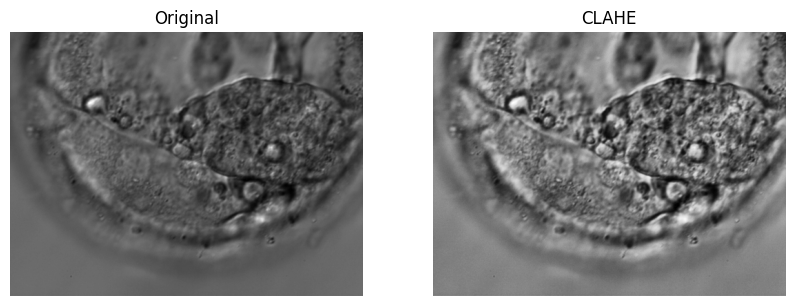

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(clahe_img, cmap='gray')
plt.title("CLAHE")
plt.axis('off')

In [11]:
!pip install scikit-image

In [14]:
from skimage.feature import graycomatrix, graycoprops
import numpy as np

# Reduce levels (VERY IMPORTANT for GLCM performance)
image = (clahe_img / 16).astype('uint8')   # 256 → 16 levels

# Create GLCM
glcm = graycomatrix(image,
                    distances=[1],
                    angles=[0],
                    levels=16,
                    symmetric=True,
                    normed=True)

# Extract features
contrast = graycoprops(glcm, 'contrast')[0, 0]
correlation = graycoprops(glcm, 'correlation')[0, 0]
energy = graycoprops(glcm, 'energy')[0, 0]
homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

print("Contrast:", contrast)
print("Correlation:", correlation)
print("Energy:", energy)
print("Homogeneity:", homogeneity)

Contrast: 0.351424902152642
Correlation: 0.9483856396071639
Energy: 0.3187608357674601
Homogeneity: 0.8495364564424296


In [15]:
from skimage.feature import graycomatrix, graycoprops
import numpy as np
import os
import cv2

path = "/kaggle/input/datasets/iamshahzaibkhan/human-blastocyst-dataset-for-ivf/Images/Images"

features_list = []

for file in os.listdir(path):
    img_path = path + "/" + file
    
    # Read image
    img = cv2.imread(img_path, 0)
    
    if img is None:
        continue
    
    # Resize (IMPORTANT for consistency)
    img = cv2.resize(img, (128,128))
    
    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=1.8, tileGridSize=(8,8))
    clahe_img = clahe.apply(img)
    
    # Reduce levels
    image = (clahe_img / 16).astype('uint8')
    
    # GLCM
    glcm = graycomatrix(image,
                        distances=[1],
                        angles=[0],
                        levels=16,
                        symmetric=True,
                        normed=True)
    
    # Features
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    
    features_list.append([file, contrast, correlation, energy, homogeneity])

print("Done! Total processed:", len(features_list))

Done! Total processed: 2344


In [16]:
import pandas as pd

df = pd.DataFrame(features_list, columns=[
    "image_name", "contrast", "correlation", "energy", "homogeneity"
])

df.head()

,image_name,contrast,correlation,energy,homogeneity
0,678_01.png,1.519377,0.707335,0.277102,0.690216
1,754_01.png,3.393824,0.724734,0.147368,0.539099
2,808_01.png,2.680426,0.824943,0.144601,0.570708
3,210_06.png,2.977731,0.762920,0.169043,0.603401
4,719_01.png,3.702510,0.688187,0.163871,0.560709


In [19]:
df.to_csv("/kaggle/working/glcm_features.csv", index=False)

In [22]:
import os
print(os.listdir('/kaggle/input'))


['datasets']


In [25]:
print(os.listdir('/kaggle/input/datasets/iamshahzaibkhan'))

['human-blastocyst-dataset-for-ivf']


In [26]:
print(os.listdir('/kaggle/input/datasets/iamshahzaibkhan'))

['human-blastocyst-dataset-for-ivf']


In [27]:
print(os.listdir('/kaggle/input/datasets/iamshahzaibkhan/human-blastocyst-dataset-for-ivf'))

['Gardner_test_gold_onlyGardnerScores.csv', 'Images', 'Gardner_train_silver.csv']


In [31]:
print(labels_df.head())

         Image  EXP_silver  ICM_silver  TE_silver
0  0175_05.png           3           1          1
1   420_02.png           3           0          0
2   680_01.png           2           0          0
3   340_03.png           3           0          1
4   571_02.png           0           3          3


In [33]:
labels_df.columns = labels_df.columns.str.strip().str.lower()

In [34]:
print(labels_df.head())

         image  exp_silver  icm_silver  te_silver
0  0175_05.png           3           1          1
1   420_02.png           3           0          0
2   680_01.png           2           0          0
3   340_03.png           3           0          1
4   571_02.png           0           3          3


In [36]:
features_df = pd.read_csv('/kaggle/working/glcm_features.csv')
print(features_df.columns)
print(labels_df.columns)

Index(['image_name', 'contrast', 'correlation', 'energy', 'homogeneity'], dtype='object')
Index(['image', 'exp_silver', 'icm_silver', 'te_silver'], dtype='object')


In [37]:
features_df = features_df.rename(columns={'image_name': 'image'})

In [38]:
features_df = pd.read_csv('/kaggle/working/glcm_features.csv')
print(features_df.columns)
print(labels_df.columns)

Index(['image_name', 'contrast', 'correlation', 'energy', 'homogeneity'], dtype='object')
Index(['image', 'exp_silver', 'icm_silver', 'te_silver'], dtype='object')


In [39]:
features_df = pd.read_csv('/kaggle/working/glcm_features.csv')

# 🔥 Fix column name
features_df.rename(columns={'image_name': 'image'}, inplace=True)

print(features_df.columns)
print(labels_df.columns)

Index(['image', 'contrast', 'correlation', 'energy', 'homogeneity'], dtype='object')
Index(['image', 'exp_silver', 'icm_silver', 'te_silver'], dtype='object')


In [40]:
df = pd.merge(features_df, labels_df, on='image')

print(df.shape)
print(df.head())

(2044, 8)
        image  contrast  correlation    energy  homogeneity  exp_silver  \
0  754_01.png  3.393824     0.724734  0.147368     0.539099           3   
1  808_01.png  2.680426     0.824943  0.144601     0.570708           3   
2  210_06.png  2.977731     0.762920  0.169043     0.603401           3   
3  719_01.png  3.702510     0.688187  0.163871     0.560709           3   
4  712_01.png  3.430118     0.736258  0.159130     0.575854           3   

   icm_silver  te_silver  
0           0          0  
1           0          0  
2           0          1  
3           0          0  
4           0          0  


In [41]:
# ==============================
# 1. DEFINE FEATURES & TARGET
# ==============================

X = df[['contrast', 'correlation', 'energy', 'homogeneity']]
y = df[['exp_silver', 'icm_silver', 'te_silver']]

# ==============================
# 2. TRAIN-TEST SPLIT
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 3. (OPTIONAL BUT GOOD) SCALING
# ==============================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 4. TRAIN MODEL
# ==============================

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

# ==============================
# 5. PREDICT
# ==============================

y_pred = model.predict(X_test)

# ==============================
# 6. EVALUATE
# ==============================

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

# ==============================
# 7. SEE SAMPLE OUTPUT
# ==============================

print("\nExample Prediction:")
print("Actual:   ", y_test.iloc[0].values)
print("Predicted:", y_pred[0])

MSE: 0.9917718409843156

Example Prediction:
Actual:    [3 0 0]
Predicted: [2.7725 0.305  1.095 ]
